# Baseline

**과제**: 자연 풍경 사진을 6개 클래스로 분류한다 —  
`buildings` / `forest` / `glacier` / `mountain` / `sea` / `street` · **지표는 Accuracy**

## 0. 환경 확인

In [1]:
import os, time, math, random, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0),
          f"| {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("⚠️  GPU가 꺼져 있습니다. 런타임 → 런타임 유형 변경 → T4 GPU 로 켜고 다시 실행하세요.")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

torch 2.11.0+cu128 | device: cuda
GPU: Tesla T4 | 15.6 GB


## 1. 데이터 받기

In [9]:
# 데이터 다운로드 받아서 zip 파일 압축 해제
# 업로드한 deeptest.zip 압축 풀기
!unzip -q -o /content/deeptest.zip -d /content/data

import pandas as pd
from pathlib import Path

DATA = Path("/content/data")
if not DATA.exists():
    DATA = Path("../out")

train_df = pd.read_csv(DATA / "train.csv", dtype={"id": str})
sub      = pd.read_csv(DATA / "sample_submission.csv", dtype={"id": str})
CLASSES  = sorted(train_df["label"].unique())
C2I      = {c: i for i, c in enumerate(CLASSES)}

print("train", train_df.shape, "| test", sub.shape)
print("클래스:", CLASSES)
print(train_df["label"].value_counts().to_string())

train (14034, 2) | test (3000, 2)
클래스: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
label
mountain     2512
glacier      2404
street       2382
sea          2274
forest       2271
buildings    2191


## 2. 이미지를 통째로 RAM에 올린다

In [13]:
from PIL import Image

IMG = 128        # 배포된 이미지 크기

def load_split(folder, ids):
    X = torch.empty(len(ids), 3, IMG, IMG, dtype=torch.uint8)
    for i, fid in enumerate(ids):
        im = Image.open(folder / f"{fid}.jpg").convert("RGB")
        if im.size != (IMG, IMG): im = im.resize((IMG, IMG), Image.BILINEAR)
        X[i] = torch.from_numpy(np.asarray(im)).permute(2, 0, 1)
        if (i+1) % 2000 == 0: print(f"  {i+1}/{len(ids)}", end="\r")
    return X

CACHE = Path("cache.pt")
if CACHE.exists():
    blob = torch.load(CACHE); Xtr_all, Xte = blob["tr"], blob["te"]
    print("캐시에서 로드")
else:
    t0 = time.time()

    Xtr_all = load_split(DATA/"images/train", train_df["id"].tolist())
    Xte     = load_split(DATA/"images/test",  sub["id"].tolist())

    torch.save({"tr": Xtr_all, "te": Xte}, CACHE)
    print(f"이미지 로드 {time.time()-t0:.1f}s")

ytr_all = torch.tensor([C2I[l] for l in train_df["label"]])
print(f"train {tuple(Xtr_all.shape)}  test {tuple(Xte.shape)}  "
      f"메모리 {(Xtr_all.numel()+Xte.numel())/1e6:.0f} MB")

이미지 로드 16.5s
train (14034, 3, 128, 128)  test (3000, 3, 128, 128)  메모리 837 MB


> **왜 이렇게 하는가**: Colab에서 이미지 학습이 느린 가장 흔한 원인은 GPU가 아니라  
> **매 epoch마다 JPEG를 디스크에서 읽고 디코딩하는 것**입니다.  
> 한 번 `uint8` 텐서로 올려 두면 그 비용이 사라지고, 이 데이터는 다 합쳐 몇백 MB라 RAM에 충분히 들어갑니다.  
> `cache.pt`로 저장해 두면 **세션이 끊겨도 다시 읽을 필요가 없습니다.** (Colab에서 중요)

## 3. 데이터 분리

In [14]:
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms

idx_tr, idx_va = train_test_split(np.arange(len(ytr_all)), test_size=0.15,
                                  stratify=ytr_all.numpy(), random_state=SEED)
print(f"학습 {len(idx_tr):,} / 검증 {len(idx_va):,}")

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(DEVICE)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(DEVICE)

train_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(IMG, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
])

def batches(X, y, idx, bs, shuffle, is_train=False):
    order = np.random.permutation(idx) if shuffle else idx
    for i in range(0, len(order), bs):
        sel = order[i:i+bs]
        xb = X[sel].to(DEVICE, non_blocking=True).float().div_(255)

        if is_train:
            xb = train_aug(xb)

        xb = (xb - MEAN) / STD
        yield xb, (y[sel].to(DEVICE) if y is not None else None)

학습 11,928 / 검증 2,106


## 4. 간단한 CNN

In [15]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes, width=32):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                nn.MaxPool2d(2))
        self.features = nn.Sequential(
            block(3, width),            # 128 -> 64
            block(width, width*2),      #  64 -> 32
            block(width*2, width*4),    #  32 -> 16
            block(width*4, width*8),    #  16 ->  8
        )
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(0.2), nn.Linear(width*8, n_classes))
    def forward(self, x): return self.head(self.features(x))

model = SimpleCNN(len(CLASSES)).to(DEVICE)
print(f"파라미터 수: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

파라미터 수: 1.17M


## 5. 학습

In [16]:
EPOCHS, BS, LR = 20, 128, 3e-3
opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
crit  = nn.CrossEntropyLoss()
USE_AMP = (DEVICE == "cuda")
scaler  = torch.amp.GradScaler(DEVICE, enabled=USE_AMP)

@torch.no_grad()
def evaluate(X, y, idx):
    model.eval(); correct = 0
    for xb, yb in batches(X, y, idx, 256, False, is_train=False): # 평가 시에는 증강 끔
        with torch.amp.autocast(DEVICE, enabled=USE_AMP):
            correct += (model(xb).argmax(1) == yb).sum().item()
    return correct / len(idx)

hist, best, t0 = [], 0.0, time.time()
for ep in range(1, EPOCHS+1):
    model.train(); tot = n = 0

    for xb, yb in batches(Xtr_all, ytr_all, idx_tr, BS, True, is_train=True):
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast(DEVICE, enabled=USE_AMP):
            loss = crit(model(xb), yb)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        tot += loss.item()*len(yb); n += len(yb)
    sched.step()

    tr_acc = evaluate(Xtr_all, ytr_all, idx_tr)
    va_acc = evaluate(Xtr_all, ytr_all, idx_va)

    hist.append({"epoch": ep, "loss": tot/n, "train_acc": tr_acc, "val_acc": va_acc})
    if va_acc > best:
        best = va_acc; torch.save(model.state_dict(), "best.pt")
    print(f"  ep{ep:2d}  loss={tot/n:.4f}  train={tr_acc:.4f}  val={va_acc:.4f}"
          f"{'  <- best' if va_acc==best else ''}")

print(f"\n총 {time.time()-t0:.1f}s  |  best val accuracy = {best:.4f}")

  ep 1  loss=1.0439  train=0.4302  val=0.4330  <- best
  ep 2  loss=0.7752  train=0.6550  val=0.6600  <- best
  ep 3  loss=0.6110  train=0.7370  val=0.7422  <- best
  ep 4  loss=0.5483  train=0.7200  val=0.7061
  ep 5  loss=0.5153  train=0.8043  val=0.8053  <- best
  ep 6  loss=0.4696  train=0.7788  val=0.7806
  ep 7  loss=0.4346  train=0.8603  val=0.8452  <- best
  ep 8  loss=0.4142  train=0.8460  val=0.8343
  ep 9  loss=0.3917  train=0.8700  val=0.8585  <- best
  ep10  loss=0.3646  train=0.8634  val=0.8566
  ep11  loss=0.3516  train=0.8421  val=0.8348
  ep12  loss=0.3283  train=0.8836  val=0.8632  <- best
  ep13  loss=0.3104  train=0.8853  val=0.8813  <- best
  ep14  loss=0.2918  train=0.8962  val=0.8813  <- best
  ep15  loss=0.2753  train=0.9134  val=0.8908  <- best
  ep16  loss=0.2627  train=0.9107  val=0.8908  <- best
  ep17  loss=0.2516  train=0.9204  val=0.8993  <- best
  ep18  loss=0.2459  train=0.9215  val=0.8955
  ep19  loss=0.2349  train=0.9276  val=0.9046  <- best
  ep20  l

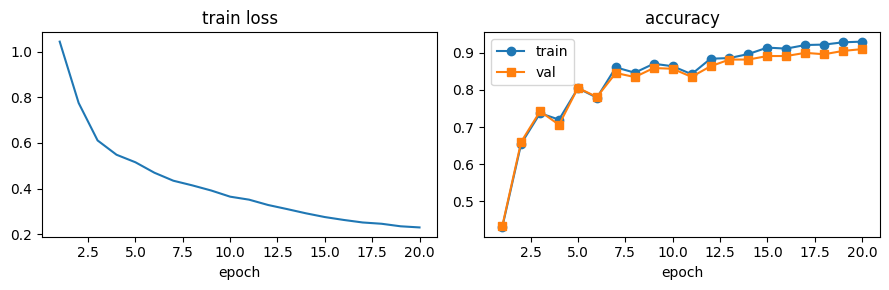

마지막 epoch  train 0.9295  vs  val 0.9093   차이 +0.0202


In [17]:
import matplotlib.pyplot as plt
h = pd.DataFrame(hist)
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(h.epoch, h.loss); ax[0].set_title("train loss"); ax[0].set_xlabel("epoch")
ax[1].plot(h.epoch, h.train_acc, "o-", label="train")
ax[1].plot(h.epoch, h.val_acc,  "s-", label="val")
ax[1].set_title("accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"마지막 epoch  train {h.train_acc.iloc[-1]:.4f}  vs  val {h.val_acc.iloc[-1]:.4f}"
      f"   차이 {h.train_acc.iloc[-1]-h.val_acc.iloc[-1]:+.4f}")

> ## 오른쪽 그래프의 두 선 사이 간격을 보세요
>
> 학습 정확도는 계속 올라가는데 검증 정확도는 어느 순간부터 안 올라갑니다.  
> **간격이 벌어지는 것 = 과적합**입니다. 모델이 문제를 푸는 게 아니라 **학습 이미지를 외우고** 있습니다.
>
> 지금 우리는 **정규화 말고는 아무 처리도 안 한 원본 이미지**를 매 epoch 똑같이 보여주고 있습니다.  
> 같은 사진 9천 장을 15번 반복해서 보면, 외우는 게 당연합니다.
>
> **데이터 증강**: 매번 **조금씩 다른 사진**을 보여주면 어떻게 될까요?  
> 좌우로 뒤집고, 살짝 잘라내고, 밝기를 바꾸면 — 사람 눈에는 여전히 같은 "숲"이지만  
> 모델에게는 새로운 이미지입니다.

## 6. 제출 파일 만들기

In [18]:
model.load_state_dict(torch.load("best.pt"))       # 검증 최고 시점으로 되돌린다
model.eval()
preds = []
with torch.no_grad():
    for xb, _ in batches(Xte, None, np.arange(len(Xte)), 256, False):
        with torch.amp.autocast(DEVICE, enabled=USE_AMP):
            preds.append(model(xb).argmax(1).cpu())
pred = torch.cat(preds).numpy()

submission = pd.DataFrame({"id": sub["id"], "label": [CLASSES[i] for i in pred]})
assert len(submission) == len(sub),          f"행 수 불일치 {len(submission)} vs {len(sub)}"
assert set(submission["id"]) == set(sub["id"]), "id 집합 불일치"
assert set(submission["label"]) <= set(CLASSES), "허용되지 않는 클래스 값"
submission.to_csv("submission.csv", index=False)

print("submission.csv 생성 완료\n")
print("예측 분포(%)\n" + (submission["label"].value_counts(normalize=True)*100).round(2).to_string())
print("\n학습 분포(%)\n" + (train_df["label"].value_counts(normalize=True)*100).round(2).to_string())
submission.head()

submission.csv 생성 완료

예측 분포(%)
label
glacier      18.13
mountain     17.53
sea          17.33
street       17.00
forest       16.17
buildings    13.83

학습 분포(%)
label
mountain     17.90
glacier      17.13
street       16.97
sea          16.20
forest       16.18
buildings    15.61


,id,label
0,500000,forest
1,500001,street
2,500002,sea
3,500003,sea
4,500004,glacier
